In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy import stats
import os
import smarts_cerebellum.globals as gl

In [3]:
rois = ['M1', 'M2', 'M3', 'M4',
        'A1', 'A2', 'A3', 
        'D1', 'D2', 'D3', 'D4', 
        'S1', 'S2', 'S3', 'S4', 'S5']

In [4]:
df_GM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_Nettekoven_2024_GM_mod_slope.tsv'), sep = '\t')
df_GM['hemisphere'] = df_GM.regionname.str[2]

In [ ]:
for roi in rois:
    patient_df_l = df_GM[(df_GM.regionname == roi + 'L') & (df_GM.isPatient==1)]
    patient_df_r = df_GM[(df_GM.regionname == roi + 'R') & (df_GM.isPatient==1)]
    
    patients_r = np.array(patient_df_r['mean'])
    patients_l = np.array(patient_df_l['mean'])

    t_val, p_val = stats.ttest_rel(patients_l, patients_r)

    print(f'**t-test for GM in {roi}L vs {roi}R** \n t-value: {t_val} \t p-value: {p_val}')


**t-test for GM in M1L vs M1R** 
 t-value: -1.5113329369131143 	 p-value: 0.13968074768126434
**t-test for GM in M2L vs M2R** 
 t-value: -3.4547994820854173 	 p-value: 0.0014603750828704248
**t-test for GM in M3L vs M3R** 
 t-value: -1.9999628169657224 	 p-value: 0.053311851966621124
**t-test for GM in M4L vs M4R** 
 t-value: -2.3442936080738805 	 p-value: 0.024866326224648582
**t-test for GM in A1L vs A1R** 
 t-value: -0.13077519458477496 	 p-value: 0.8967019390024245
**t-test for GM in A2L vs A2R** 
 t-value: -1.5446544655836116 	 p-value: 0.1314246805951808
**t-test for GM in A3L vs A3R** 
 t-value: -1.641349725121768 	 p-value: 0.10968194810121144
**t-test for GM in D1L vs D1R** 
 t-value: -3.401519892445204 	 p-value: 0.001690790815340091
**t-test for GM in D2L vs D2R** 
 t-value: -2.3864339984866296 	 p-value: 0.022552199923566194
**t-test for GM in D3L vs D3R** 
 t-value: -0.011741308804447908 	 p-value: 0.9906986791295753
**t-test for GM in D4L vs D4R** 
 t-value: -1.7756449583

In [ ]:
controls_bilat = controls.groupby('subj_id').agg({'mean': 'mean'}).reset_index()
    controls_bilat['regionname'] = f'bilat_{tract}'
    controls_bilat['isPatient'] = 0

In [29]:
controls_df

,image,image_name,frame,region,regionname,volume,atlas,map,space,mean,...,ID,Centre,RefT1,age,Gender,isPatient,LesionSide,LesionLocation,handedness,hemisphere
0,1,CUP_1001_MNISymC_GM_mod_slope.nii.gz,0,1,M1L,1652.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.012343,...,1001,CUP,W0,67,M,0,none,none,2,L
1,1,CUP_1001_MNISymC_GM_mod_slope.nii.gz,0,2,M2L,6578.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.010411,...,1001,CUP,W0,67,M,0,none,none,2,L
2,1,CUP_1001_MNISymC_GM_mod_slope.nii.gz,0,3,M3L,7296.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.009893,...,1001,CUP,W0,67,M,0,none,none,2,L
3,1,CUP_1001_MNISymC_GM_mod_slope.nii.gz,0,4,M4L,3542.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.010749,...,1001,CUP,W0,67,M,0,none,none,2,L
4,1,CUP_1001_MNISymC_GM_mod_slope.nii.gz,0,5,A1L,1029.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.016439,...,1001,CUP,W0,67,M,0,none,none,2,L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,1,UZP_1008_MNISymC_GM_mod_slope.nii.gz,0,28,S1R,6886.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.001453,...,1008,UZP,W0,63,M,0,none,none,2,R
732,1,UZP_1008_MNISymC_GM_mod_slope.nii.gz,0,29,S2R,11131.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,-0.000761,...,1008,UZP,W0,63,M,0,none,none,2,R
733,1,UZP_1008_MNISymC_GM_mod_slope.nii.gz,0,30,S3R,442.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,-0.001407,...,1008,UZP,W0,63,M,0,none,none,2,R
734,1,UZP_1008_MNISymC_GM_mod_slope.nii.gz,0,31,S4R,4263.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.001943,...,1008,UZP,W0,63,M,0,none,none,2,R


In [41]:
controls_df = df_GM[df_GM.isPatient == 0].copy()
controls_df['region_bilat'] = controls_df.regionname.str[:2]
controls_bilat = controls_df.groupby(['subj_id', 'region_bilat']).agg({'mean': 'mean'}).reset_index()

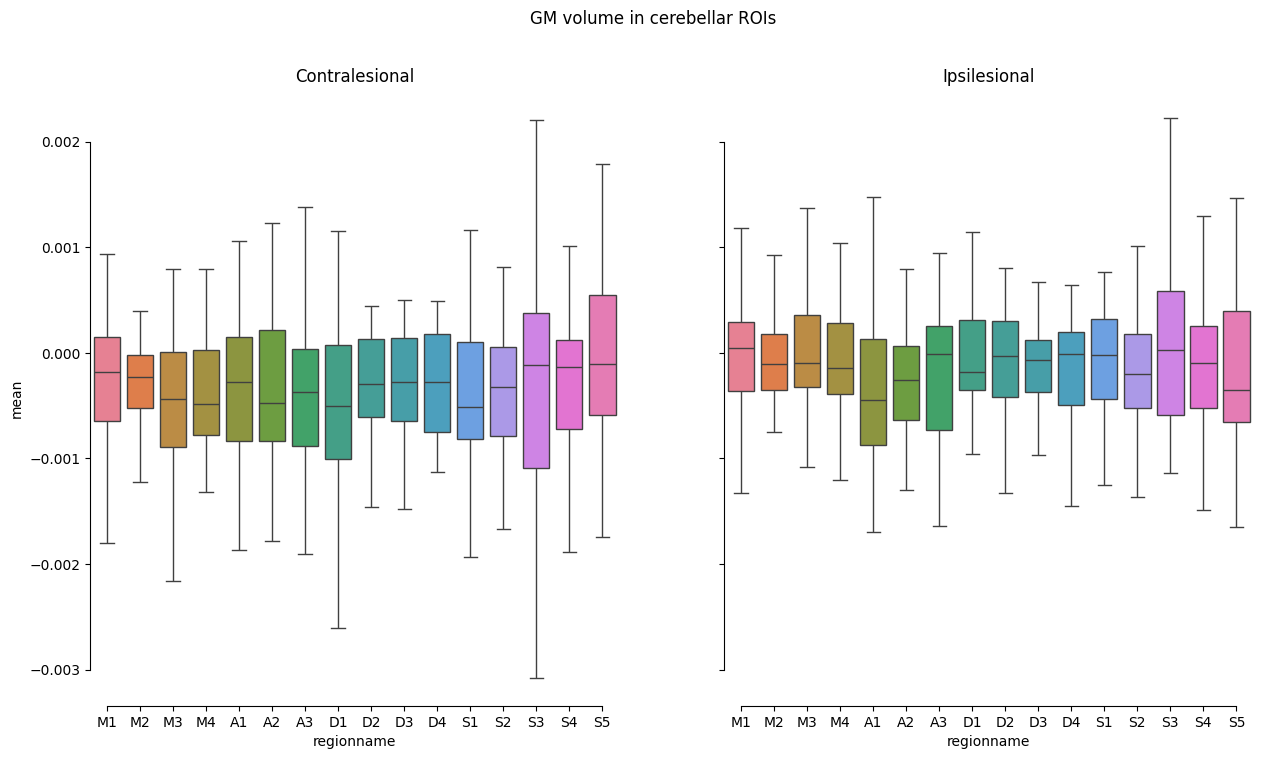

In [ ]:
patients_df = df_GM[df_GM.isPatient == 1]
plot_l = patients_df[patients_df.regionname.str[2]=='L'] # contralesional
plot_r = patients_df[patients_df.regionname.str[2]=='R'] # ipsilesional

controls_df = df_GM[df_GM.isPatient == 0].copy()
controls_df['region_bilat'] = controls_df.regionname.str[:2]
controls_bilat = controls_df.groupby(['subj_id', 'region_bilat']).agg({'mean': 'mean'}).reset_index()



fig, axs = plt.subplots(1,2, figsize = (15,8), sharey = True)
sns.boxplot(data = plot_l, x = 'regionname', y = 'mean', hue = 'regionname', showfliers = False, ax = axs[0])
sns.boxplot(data = plot_r, x = 'regionname', y = 'mean', hue = 'regionname', showfliers = False, ax = axs[1])

axs[0].set_title("Contralesional")
axs[1].set_title("Ipsilesional")


#plt.legend(bbox_to_anchor = (1, .7))
for ax in axs:
    ax.set_xticks(ticks = np.arange(len(rois)), labels = rois)

plt.suptitle("GM volume in cerebellar ROIs")
sns.despine(trim = True)
plt.show()